In [ ]:
# Import libraries yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Libraries untuk preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Libraries untuk model
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Set random seed untuk reproducibility
np.random.seed(42)

In [ ]:
df = pd.read_csv('seattle-weather.csv')
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [ ]:
df.shape

(1461, 6)

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [ ]:
df.sample()

,date,precipitation,temp_max,temp_min,wind,weather
892,2014-06-11,0.0,23.9,11.1,2.7,sun


In [ ]:
df.isnull().sum()

,0
date,0
precipitation,0
temp_max,0
temp_min,0
wind,0
weather,0


In [ ]:
weather_counts = df['weather'].value_counts()
df['weather'].value_counts()

,count
weather,
rain,641
sun,640
fog,101
drizzle,53
snow,26


In [ ]:
# Konversi kolom date ke datetime
df['date'] = pd.to_datetime(df['date'])

# Ekstraksi fitur temporal
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek
df['quarter'] = df['date'].dt.quarter
df['dayofyear'] = df['date'].dt.dayofyear

# Tambahkan fitur siklikal untuk bulan dan hari
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['day_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['day_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)

print("Fitur baru yang ditambahkan:")
df[['date', 'year', 'month', 'day', 'dayofweek', 'quarter', 'dayofyear']].head()

Fitur baru yang ditambahkan:


,date,year,month,day,dayofweek,quarter,dayofyear
0,2012-01-01,2012,1,1,6,1,1
1,2012-01-02,2012,1,2,0,1,2
2,2012-01-03,2012,1,3,1,1,3
3,2012-01-04,2012,1,4,2,1,4
4,2012-01-05,2012,1,5,3,1,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1461 non-null   datetime64[ns]
 1   precipitation  1461 non-null   float64       
 2   temp_max       1461 non-null   float64       
 3   temp_min       1461 non-null   float64       
 4   wind           1461 non-null   float64       
 5   weather        1461 non-null   object        
 6   year           1461 non-null   int32         
 7   month          1461 non-null   int32         
 8   day            1461 non-null   int32         
 9   dayofweek      1461 non-null   int32         
 10  quarter        1461 non-null   int32         
 11  dayofyear      1461 non-null   int32         
 12  month_sin      1461 non-null   float64       
 13  month_cos      1461 non-null   float64       
 14  day_sin        1461 non-null   float64       
 15  day_cos        1461 n

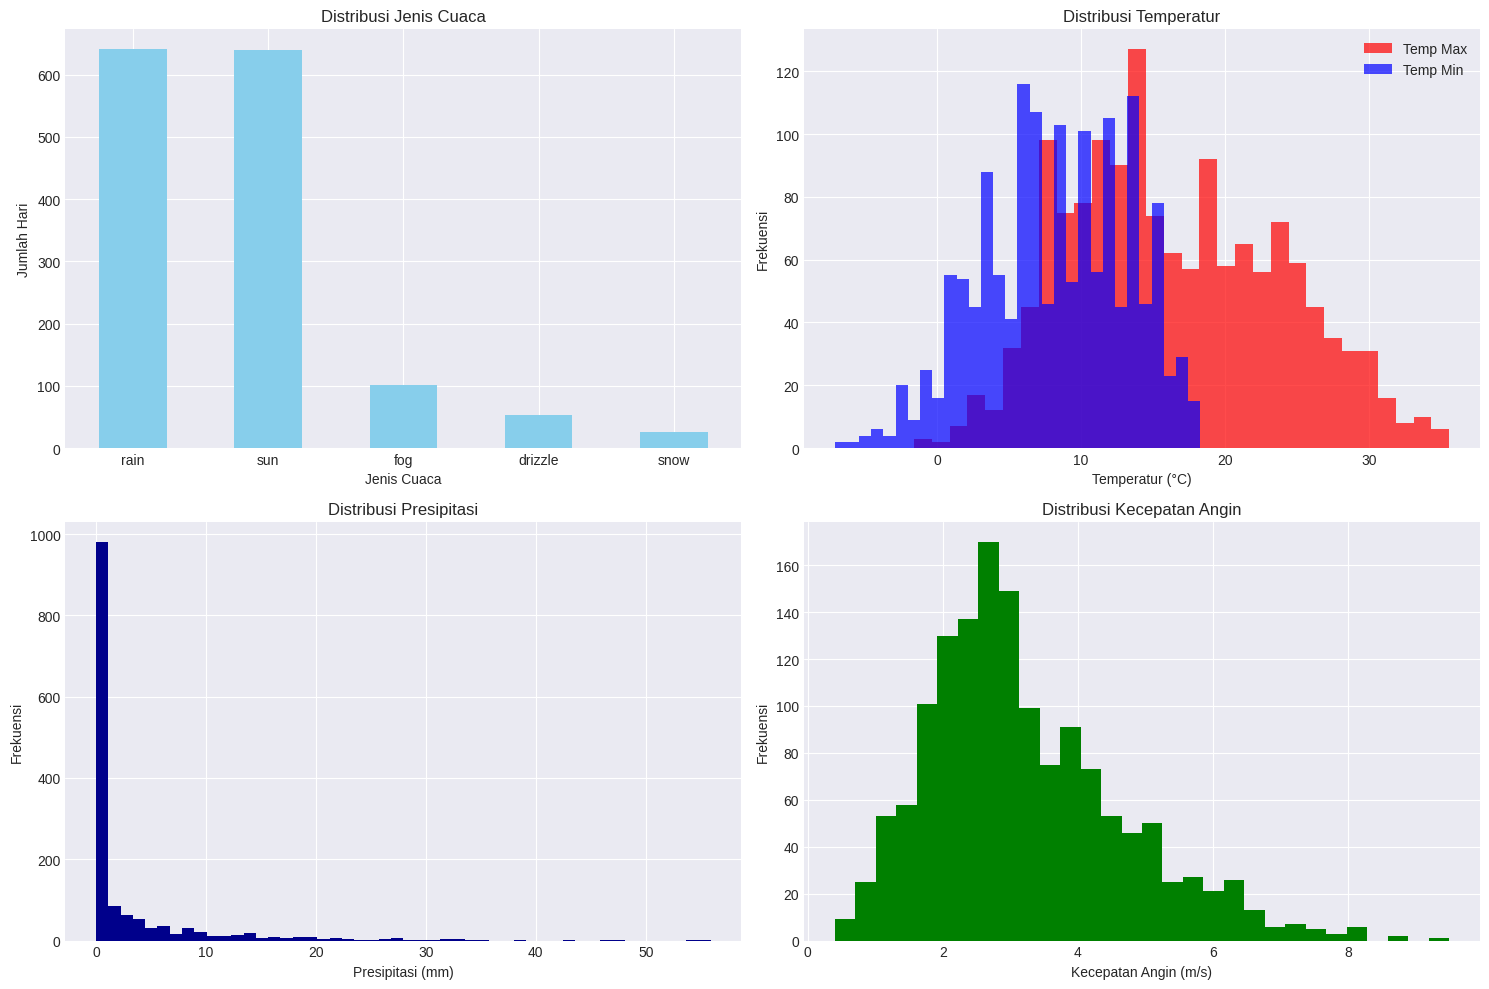

In [ ]:
fig = plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
weather_counts.plot(kind='bar', color='skyblue')
plt.title('Distribusi Jenis Cuaca')
plt.xlabel('Jenis Cuaca')
plt.ylabel('Jumlah Hari')
plt.xticks(rotation=0)

plt.subplot(2, 2, 2)
plt.hist(df['temp_max'], bins=30, alpha=0.7, label='Temp Max', color='red')
plt.hist(df['temp_min'], bins=30, alpha=0.7, label='Temp Min', color='blue')
plt.title('Distribusi Temperatur')
plt.xlabel('Temperatur (°C)')
plt.ylabel('Frekuensi')
plt.legend()

plt.subplot(2, 2, 3)
plt.hist(df['precipitation'], bins=50, color='darkblue')
plt.title('Distribusi Presipitasi')
plt.xlabel('Presipitasi (mm)')
plt.ylabel('Frekuensi')

plt.subplot(2, 2, 4)
plt.hist(df['wind'], bins=30, color='green')
plt.title('Distribusi Kecepatan Angin')
plt.xlabel('Kecepatan Angin (m/s)')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

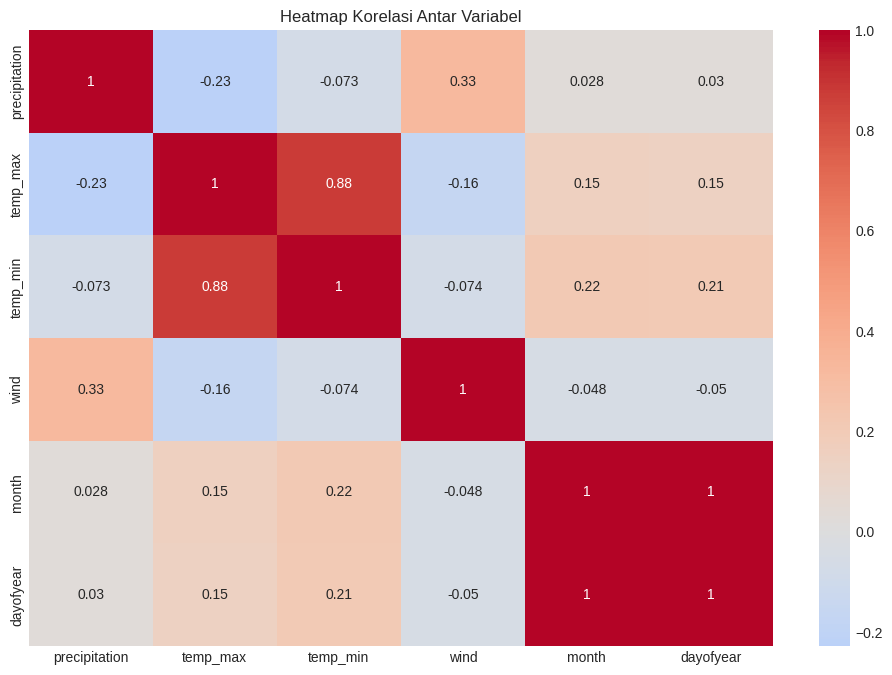

In [ ]:
# Heatmap korelasi untuk variabel numerik
plt.figure(figsize=(12, 8))
numeric_cols = ['precipitation', 'temp_max', 'temp_min', 'wind', 'month', 'dayofyear']
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi Antar Variabel')
plt.show()

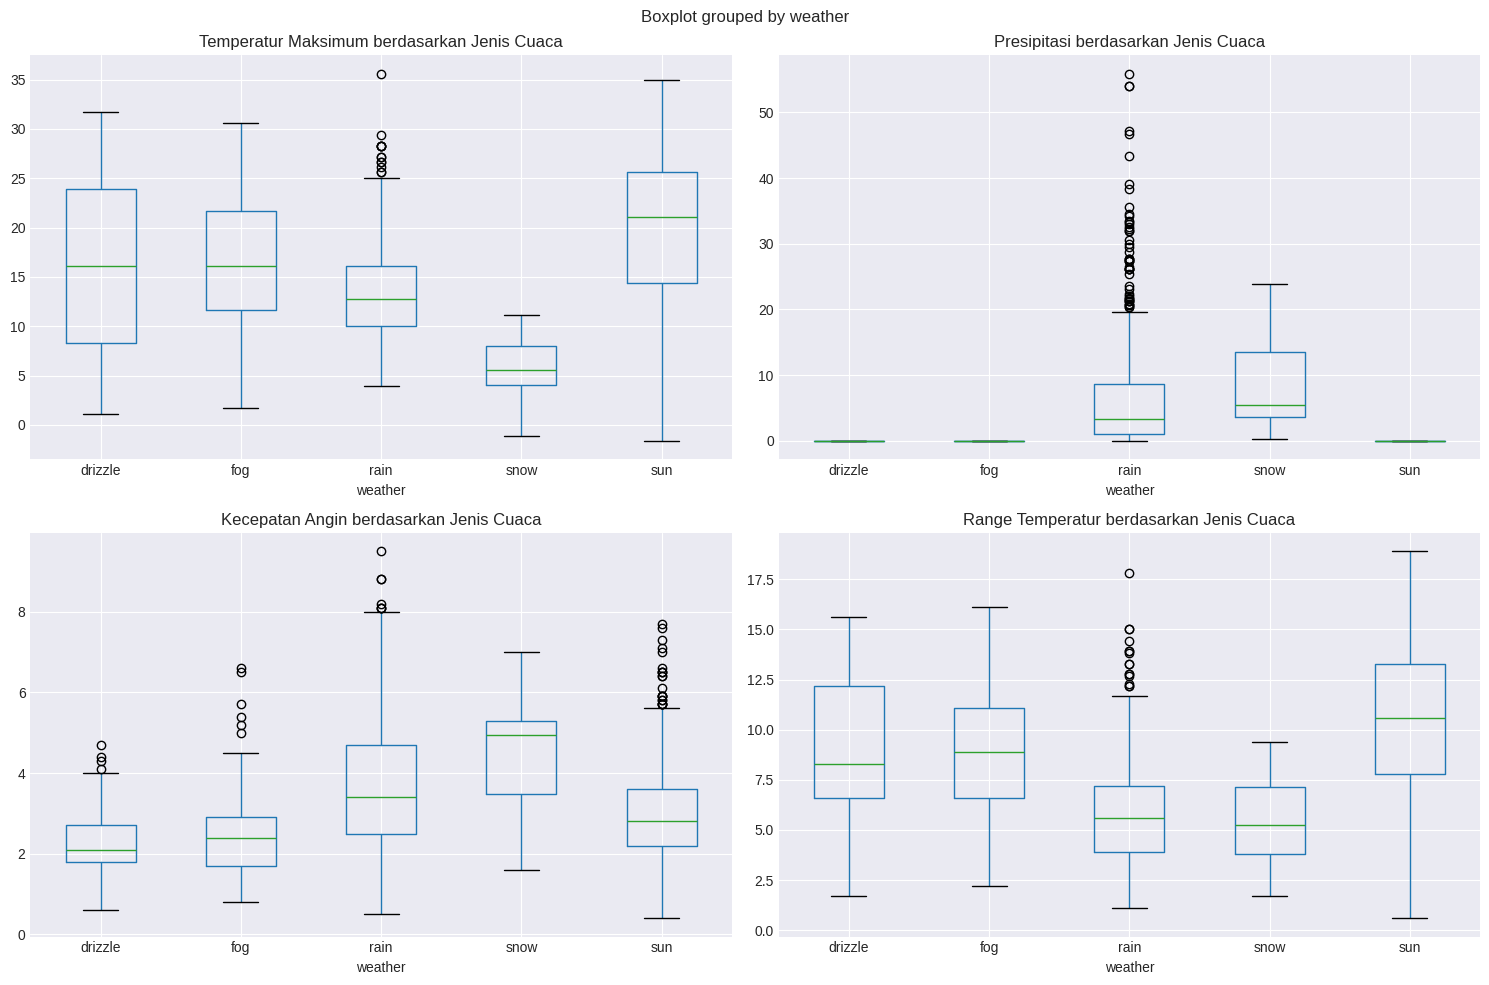

In [ ]:
# Boxplot untuk melihat hubungan cuaca dengan variabel lainnya
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Temperatur vs Cuaca
df.boxplot(column='temp_max', by='weather', ax=axes[0, 0])
axes[0, 0].set_title('Temperatur Maksimum berdasarkan Jenis Cuaca')

# Presipitasi vs Cuaca
df.boxplot(column='precipitation', by='weather', ax=axes[0, 1])
axes[0, 1].set_title('Presipitasi berdasarkan Jenis Cuaca')

# Wind vs Cuaca
df.boxplot(column='wind', by='weather', ax=axes[1, 0])
axes[1, 0].set_title('Kecepatan Angin berdasarkan Jenis Cuaca')

# Temperatur range vs Cuaca
df['temp_range'] = df['temp_max'] - df['temp_min']
df.boxplot(column='temp_range', by='weather', ax=axes[1, 1])
axes[1, 1].set_title('Range Temperatur berdasarkan Jenis Cuaca')

plt.tight_layout()
plt.show()

<Figure size 1500x600 with 0 Axes>

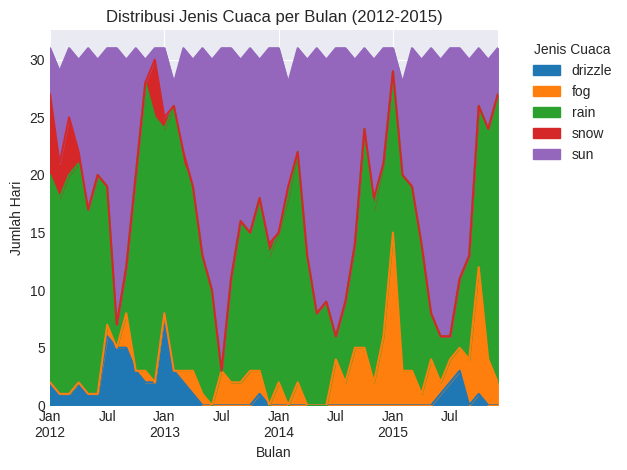

<Figure size 1500x500 with 0 Axes>

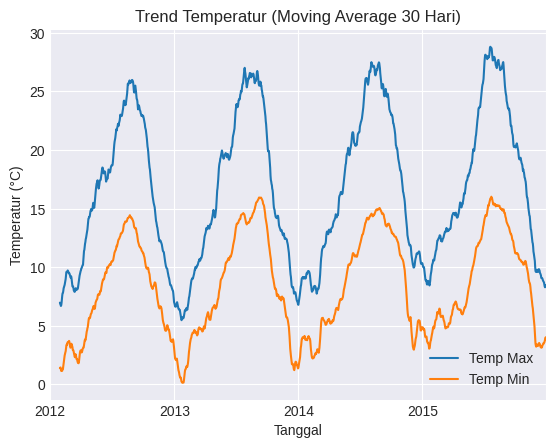

In [ ]:
# Agregasi data bulanan
monthly_weather = df.groupby([df['date'].dt.to_period('M'), 'weather']).size().unstack(fill_value=0)

# Plot time series cuaca bulanan
plt.figure(figsize=(15, 6))
monthly_weather.plot(kind='area', stacked=True)
plt.title('Distribusi Jenis Cuaca per Bulan (2012-2015)')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Hari')
plt.legend(title='Jenis Cuaca', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Trend temperatur
plt.figure(figsize=(15, 5))
df.set_index('date')[['temp_max', 'temp_min']].rolling(window=30).mean().plot()
plt.title('Trend Temperatur (Moving Average 30 Hari)')
plt.xlabel('Tanggal')
plt.ylabel('Temperatur (°C)')
plt.legend(['Temp Max', 'Temp Min'])
plt.show()

In [ ]:
# Buat fitur lag untuk time series
def create_lag_features(df, columns, lag_days=[1, 3, 7]):
    df_lagged = df.copy()
    for col in columns:
        for lag in lag_days:
            df_lagged[f'{col}_lag_{lag}'] = df_lagged[col].shift(lag)
    return df_lagged

# Aplikasikan lag features
lag_columns = ['precipitation', 'temp_max', 'temp_min', 'wind']
df_features = create_lag_features(df, lag_columns)

# Buat rolling statistics
window_sizes = [3, 7]
for window in window_sizes:
    for col in lag_columns:
        df_features[f'{col}_rolling_mean_{window}'] = df_features[col].rolling(window=window).mean()
        df_features[f'{col}_rolling_std_{window}'] = df_features[col].rolling(window=window).std()

# Drop rows dengan NaN karena lag dan rolling
df_features = df_features.dropna()

print(f"Shape setelah feature engineering: {df_features.shape}")
print(f"Total fitur: {len(df_features.columns)}")

Shape setelah feature engineering: (1454, 45)
Total fitur: 45


In [ ]:
label_encoder = LabelEncoder()
df_features['weather_encoded'] = label_encoder.fit_transform(df_features['weather'])

# Tampilkan mapping
weather_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Mapping cuaca:", weather_mapping)

# Pisahkan features dan target
feature_columns = [col for col in df_features.columns
                  if col not in ['date', 'weather', 'weather_encoded']]
X = df_features[feature_columns]
y = df_features['weather_encoded']

Mapping cuaca: {'drizzle': np.int64(0), 'fog': np.int64(1), 'rain': np.int64(2), 'snow': np.int64(3), 'sun': np.int64(4)}


In [ ]:
# Standardisasi features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data dengan mempertimbangkan urutan waktu
# Gunakan 80% untuk training, 20% untuk testing
split_index = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:split_index], X_scaled[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (1163, 43)
Test set: (291, 43)


In [ ]:
print(f"Jumlah kelas pada y_test: {len(set(y_test))}")
print(f"Jumlah kelas pada y_pred_rf: {len(set(y_pred_rf))}")
print(f"Jumlah kelas pada label_encoder.classes_: {len(label_encoder.classes_)}")


Jumlah kelas pada y_test: 4
Jumlah kelas pada y_pred_rf: 2
Jumlah kelas pada label_encoder.classes_: 5


In [ ]:
print(f"Kelas pada data pelatihan: {set(y_train)}")
print(f"Kelas pada data pengujian: {set(y_test)}")


Kelas pada data pelatihan: {0, 1, 2, 3, 4}
Kelas pada data pengujian: {0, 1, 2, 4}


In [ ]:
# Training Random Forest
print("Training Random Forest Classifier...")

# Grid search untuk parameter terbaik
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Model terbaik
best_rf = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Prediksi
y_pred_rf = best_rf.predict(X_test)

# Evaluasi
print("\nRandom Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

# Menyesuaikan jumlah kelas pada classification_report untuk mencocokkan dengan y_test dan y_pred_rf
# Ambil kelas yang ada pada y_test dan y_pred_rf
classes_in_y_test = set(y_test)
classes_in_y_pred = set(y_pred_rf)
valid_classes = list(classes_in_y_test.intersection(classes_in_y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
                           labels=valid_classes,  # Hanya mengambil kelas yang ada di y_test dan y_pred_rf
                           target_names=[label_encoder.classes_[i] for i in valid_classes]))  # Sesuaikan jumlah kelas dengan target_names

Training Random Forest Classifier...
Best parameters: {'max_depth': 20, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation score: 0.8273

Random Forest Performance:
Accuracy: 0.8694

Classification Report:
              precision    recall  f1-score   support

        rain       1.00      1.00      1.00       108
         sun       0.79      1.00      0.88       145

   micro avg       0.87      1.00      0.93       253
   macro avg       0.90      1.00      0.94       253
weighted avg       0.88      1.00      0.93       253



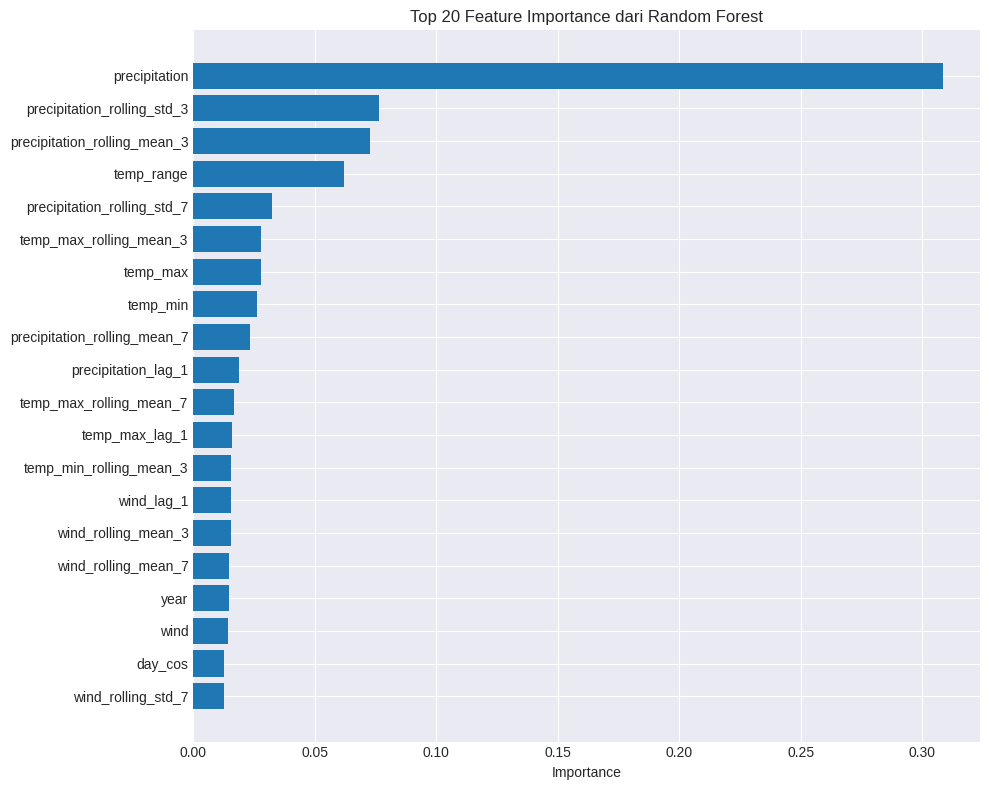

Top 10 features:
                         feature  importance
0                  precipitation    0.308401
28   precipitation_rolling_std_3    0.076219
27  precipitation_rolling_mean_3    0.072582
14                    temp_range    0.061988
36   precipitation_rolling_std_7    0.032365
29       temp_max_rolling_mean_3    0.027738
1                       temp_max    0.027644
2                       temp_min    0.026055
35  precipitation_rolling_mean_7    0.023367
15           precipitation_lag_1    0.018936


In [ ]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(20)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importance dari Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(feature_importance.head(10))